<a href="https://colab.research.google.com/github/miguelgarciavidal-anjeluz/gestion-proyectos-ia/blob/main/Actividad-04/notebook_multimodal_text_to_image_m4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aplicación multimodal: generación de imágenes a partir de texto

Notebook académico para comparar **tres modelos base de text-to-image** mediante Hugging Face Diffusers, con soporte para **Apple Silicon M4 (MPS)**, CUDA y CPU.

> **Importante sobre métricas:** accuracy, precision, recall y F1 no son métricas nativas de calidad generativa. En este notebook se calculan sobre una tarea de evaluación explícita: *¿la imagen generada coincide semánticamente con el concepto/etiqueta esperada?* Para ello se usa CLIP y un umbral configurable. Se reporta además `clip_score` y latencia, que resultan más naturales para comparar generación text-to-image.


## 1. Instalación de dependencias

Ejecuta la siguiente celda una sola vez. En una Mac M4 se recomienda un Python nativo `arm64`. Reinicia el kernel si Jupyter lo solicita después de instalar.


In [ ]:
#%pip install -U torch torchvision
#%pip install -U diffusers transformers accelerate safetensors huggingface_hub
#%pip install -U scikit-learn pandas matplotlib pillow


## 2. Validación del dispositivo: CUDA, Apple M4/MPS o CPU

En Apple Silicon se utiliza el backend **MPS (Metal Performance Shaders)** de PyTorch. El código detecta el chip y selecciona `mps` cuando está disponible. Para operaciones no implementadas en MPS se habilita el fallback a CPU.


In [1]:
import os, platform, subprocess, torch

os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")

def hardware_info():
    chip = platform.processor()
    if platform.system() == "Darwin":
        try:
            chip = subprocess.check_output(["sysctl", "-n", "machdep.cpu.brand_string"], text=True).strip()
        except Exception:
            pass
    mps_available = bool(hasattr(torch.backends, "mps") and torch.backends.mps.is_available())
    cuda_available = torch.cuda.is_available()
    device = "mps" if mps_available else ("cuda" if cuda_available else "cpu")
    return {
        "sistema": platform.platform(), "arquitectura": platform.machine(),
        "chip": chip, "pytorch": torch.__version__,
        "mps_disponible": mps_available, "cuda_disponible": cuda_available,
        "dispositivo_seleccionado": device
    }

HW = hardware_info()
HW


{'sistema': 'Linux-6.6.122+-x86_64-with-glibc2.39',
 'arquitectura': 'x86_64',
 'chip': 'x86_64',
 'pytorch': '2.11.0+cu130',
 'mps_disponible': False,
 'cuda_disponible': True,
 'dispositivo_seleccionado': 'cuda'}

## 3. Autenticación en Hugging Face Hub


Crea un token de lectura en tu cuenta de Hugging Face. Por seguridad, **no escribas el token directamente en el notebook**. La celda usa una variable de entorno o solicita el token sin mostrarlo. Algunos modelos pueden requerir aceptar previamente sus condiciones de acceso en el Hub.


In [2]:
import os, getpass
from huggingface_hub import login

hf_token = os.getenv("HF_TOKEN") or getpass.getpass("HF token: ")
login(token=hf_token, add_to_git_credential=False)
print("Autenticación completada.")


HF token: ··········
Autenticación completada.


## 4. Configuración y carga de tres modelos

Los identificadores se concentran en `MODEL_CONFIGS`, por lo que pueden sustituirse sin modificar la clase. Los tres valores son ejemplos de modelos compatibles con la interfaz Diffusers; la disponibilidad, licencia y requisitos deben verificarse antes de ejecutar.

Para M4 se favorece `float32` por compatibilidad. Si tu modelo y versión de PyTorch soportan `float16` establemente en MPS, puedes cambiarlo en la configuración de la clase para experimentar.


In [18]:
MODEL_CONFIGS = {
    "sd-turbo": {"model_id":"stabilityai/sd-turbo"},
    "RealVisXL_V5.0": {"model_id": "SG161222/RealVisXL_V5.0"},
    "stable-diffusion-v1-5": {"model_id": "stable-diffusion-v1-5/stable-diffusion-v1-5"},
}

MODEL_CONFIGS


{'sd-turbo': {'model_id': 'stabilityai/sd-turbo'},
 'RealVisXL_V5.0': {'model_id': 'SG161222/RealVisXL_V5.0'},
 'stable-diffusion-v1-5': {'model_id': 'stable-diffusion-v1-5/stable-diffusion-v1-5'}}

## 5. Clase configurable de generación y evaluación

La clase:
- recibe cualquier diccionario de modelos compatible con `DiffusionPipeline`;
- carga un modelo a la vez para reducir presión de memoria unificada en Apple Silicon;
- genera imágenes y mide latencia;
- evalúa similitud semántica mediante CLIP;
- transforma el score en una predicción binaria con un **umbral configurable** y calcula accuracy, precision, recall y F1;
- genera gráficas y una tabla comparativa.

**Supuesto de evaluación:** cada prompt del conjunto de prueba representa un caso positivo esperado. Para que precision/recall/F1 sean informativas se recomienda incluir también pares negativos explícitos o usar la función `evaluate_binary_pairs`, donde cada imagen se contrasta con una descripción y una etiqueta 0/1.


In [19]:
import gc, time
from typing import Dict, List, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from diffusers import DiffusionPipeline
from transformers import CLIPModel, CLIPProcessor
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

class MultiModelTextToImageEvaluator:
    def __init__(self, model_configs: Dict, device: Optional[str] = None,
                 clip_model_id: str = "openai/clip-vit-base-patch32",
                 threshold: float = 0.25):
        self.model_configs = model_configs
        self.device = device or self._best_device()
        self.threshold = threshold
        self.pipe = None
        self.loaded_name = None
        self.results = []
        # CLIP en CPU prioriza compatibilidad en Mac; cambiar a self.device si se valida MPS.
        self.clip_device = "cuda" if self.device == "cuda" else "cpu"
        self.clip_model = CLIPModel.from_pretrained(clip_model_id).to(self.clip_device)
        self.clip_processor = CLIPProcessor.from_pretrained(clip_model_id)

    @staticmethod
    def _best_device():
        if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
            return "mps"
        if torch.cuda.is_available():
            return "cuda"
        return "cpu"

    def unload(self):
        self.pipe = None
        self.loaded_name = None
        gc.collect()
        if self.device == "mps" and hasattr(torch, "mps"):
            torch.mps.empty_cache()
        elif self.device == "cuda":
            torch.cuda.empty_cache()

    def load_model(self, name: str):
        self.unload()
        cfg = self.model_configs[name]
        dtype = torch.float16 if self.device == "cuda" else torch.float32
        self.pipe = DiffusionPipeline.from_pretrained(
            cfg["model_id"], torch_dtype=dtype, use_safetensors=True
        )
        self.pipe = self.pipe.to(self.device)
        if self.device == "mps":
            try:
                self.pipe.enable_attention_slicing()
            except Exception:
                pass
        self.loaded_name = name
        return self

    def generate(self, prompt: str, *, steps: int = 20, guidance_scale: float = 7.5,
                 seed: int = 42, width: int = 512, height: int = 512):
        if self.pipe is None:
            raise RuntimeError("Primero ejecuta load_model(nombre).")
        # Generador CPU evita depender de torch.Generator(device='mps').
        generator = torch.Generator(device="cpu").manual_seed(seed)
        kwargs = dict(prompt=prompt, num_inference_steps=steps, generator=generator,
                      width=width, height=height)
        # SDXL Turbo suele trabajar con guidance_scale=0; se puede especificar al llamar.
        kwargs["guidance_scale"] = guidance_scale
        start = time.perf_counter()
        image = self.pipe(**kwargs).images[0]
        latency = time.perf_counter() - start
        return image, latency

    @torch.inference_mode()
    def clip_similarity(self, image, text: str) -> float:
        inp = self.clip_processor(text=[text], images=[image], return_tensors="pt", padding=True)
        inp = {k: v.to(self.clip_device) for k, v in inp.items()}
        out = self.clip_model(**inp)
        # Similaridad coseno entre embeddings normalizados, rango aproximado [-1, 1].
        im = out.image_embeds / out.image_embeds.norm(dim=-1, keepdim=True)
        tx = out.text_embeds / out.text_embeds.norm(dim=-1, keepdim=True)
        return float((im @ tx.T).item())

    def evaluate(self, prompts: List[str], *, steps=20, guidance_scale=7.5,
                 seed=42, width=512, height=512):
        rows = []
        for model_name in self.model_configs:
            self.load_model(model_name)
            for i, prompt in enumerate(prompts):
                image, latency = self.generate(
                    prompt, steps=steps, guidance_scale=guidance_scale,
                    seed=seed+i, width=width, height=height
                )
                score = self.clip_similarity(image, prompt)
                rows.append({"model": model_name, "prompt": prompt,
                             "clip_score": score, "latency_s": latency,
                             "y_true": 1, "y_pred": int(score >= self.threshold)})
        self.results = rows
        return pd.DataFrame(rows)

    def evaluate_binary_pairs(self, pairs, generated_images):
        # pairs: [{"text": str, "label": 0|1}, ...]
        # generated_images: lista alineada con pairs.
        y_true, y_pred, scores = [], [], []
        for pair, image in zip(pairs, generated_images):
            s = self.clip_similarity(image, pair["text"])
            scores.append(s); y_true.append(int(pair["label"])); y_pred.append(int(s >= self.threshold))
        return {
            "accuracy": accuracy_score(y_true, y_pred),
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0),
            "clip_score_mean": float(np.mean(scores))
        }

    def comparison_table(self, df: Optional[pd.DataFrame] = None):
        df = df if df is not None else pd.DataFrame(self.results)
        rows=[]
        for name, g in df.groupby("model"):
            y_true, y_pred = g["y_true"], g["y_pred"]
            rows.append({
                "modelo": name,
                "accuracy": accuracy_score(y_true, y_pred),
                "precision": precision_score(y_true, y_pred, zero_division=0),
                "recall": recall_score(y_true, y_pred, zero_division=0),
                "f1": f1_score(y_true, y_pred, zero_division=0),
                "clip_score_promedio": g["clip_score"].mean(),
                "latencia_promedio_s": g["latency_s"].mean(),
            })
        return pd.DataFrame(rows).sort_values(["f1", "latencia_promedio_s"], ascending=[False, True])

    def plot_comparison(self, table: pd.DataFrame):
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        table.set_index("modelo")[["accuracy","precision","recall","f1","clip_score_promedio"]].plot.bar(ax=axes[0])
        axes[0].set_title("Calidad y desempeño semántico")
        axes[0].set_ylim(0, 1)
        axes[0].set_ylabel("Puntuación")
        table.set_index("modelo")["latencia_promedio_s"].plot.bar(ax=axes[1])
        axes[1].set_title("Latencia promedio")
        axes[1].set_ylabel("Segundos")
        plt.tight_layout()
        return fig


## 6. Implementación y comparación

Se recomienda empezar con pocos prompts y resolución 512×512 para validar memoria y compatibilidad. **No se incluyen resultados inventados:** la tabla se crea únicamente después de ejecutar los modelos en tu equipo.


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Dispositivo: cuda


Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/372 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


...

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

,modelo,accuracy,precision,recall,f1,clip_score_promedio,latencia_promedio_s
1,sd-turbo,1.0,1.0,1.0,1.0,0.363511,3.864746
2,stable-diffusion-v1-5,1.0,1.0,1.0,1.0,0.357501,3.872409
0,RealVisXL_V5.0,1.0,1.0,1.0,1.0,0.373155,6.698839


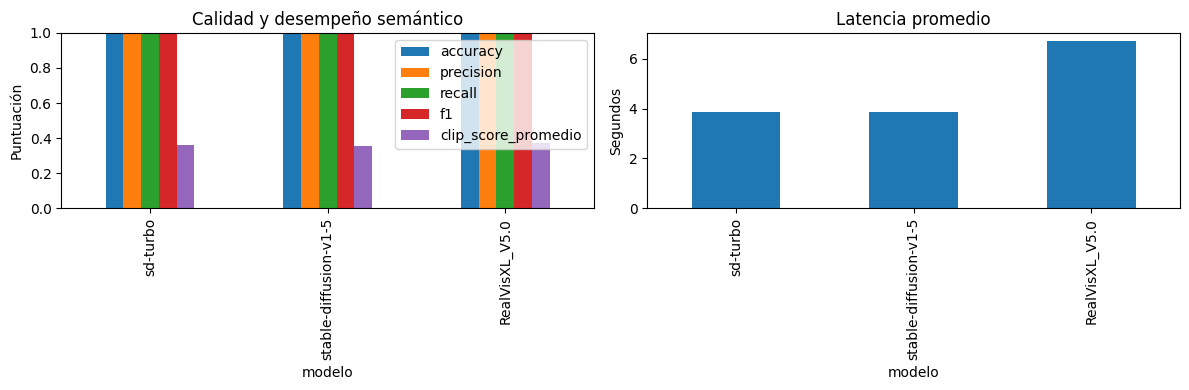

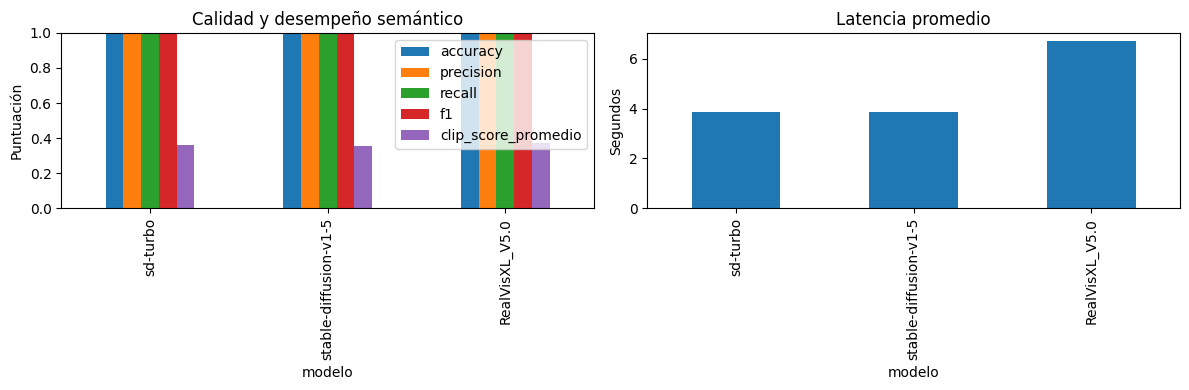

In [20]:
PROMPTS = [
    "A red vintage bicycle parked beside a blue door, photorealistic",
    "A small white robot reading a book in a modern library, cinematic light",
    "A watercolor landscape of a volcano beside a calm lake at sunrise",
]

# Asegurar limpieza de memoria previa
import gc
import torch
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()


evaluator = MultiModelTextToImageEvaluator(MODEL_CONFIGS, threshold=0.25)
print("Dispositivo:", evaluator.device)

# Ejecuta para generar el benchmark real.
raw_results = evaluator.evaluate(PROMPTS, steps=20, guidance_scale=7.5)
comparativa = evaluator.comparison_table(raw_results)
display(comparativa)
evaluator.plot_comparison(comparativa)


### 6.1 Trade-offs: eficiencia frente a precisión

Use los resultados medidos, no una expectativa teórica. Una decisión reproducible puede normalizar `F1`/`clip_score` (calidad) y latencia (eficiencia). El peso depende del caso de uso. El siguiente ejemplo aplica 60% a calidad y 40% a eficiencia; **es una política de decisión editable, no un hecho**.


In [21]:
def add_tradeoff_score(table, quality_weight=0.60, latency_weight=0.40):
    t = table.copy()
    latency = t["latencia_promedio_s"]
    lmin, lmax = latency.min(), latency.max()
    efficiency = 1 - (latency-lmin)/(lmax-lmin) if lmax > lmin else pd.Series(1.0, index=t.index)
    quality = (t["f1"] + t["clip_score_promedio"]) / 2
    t["eficiencia_norm"] = efficiency
    t["score_tradeoff"] = quality_weight*quality + latency_weight*efficiency
    return t.sort_values("score_tradeoff", ascending=False)

tradeoffs = add_tradeoff_score(comparativa)
display(tradeoffs)


,modelo,accuracy,precision,recall,f1,clip_score_promedio,latencia_promedio_s,eficiencia_norm,score_tradeoff
1,sd-turbo,1.0,1.0,1.0,1.0,0.363511,3.864746,1.000000,0.809053
2,stable-diffusion-v1-5,1.0,1.0,1.0,1.0,0.357501,3.872409,0.997296,0.806169
0,RealVisXL_V5.0,1.0,1.0,1.0,1.0,0.373155,6.698839,0.000000,0.411946


### 6.2 Decisiones de ajuste mínimo

Orden sugerido para mantener una comparación justa:
1. Mantener prompt, semilla y resolución constantes.
2. Ajustar únicamente `num_inference_steps` y `guidance_scale` según la familia del modelo.
3. En M4, activar attention slicing si existe presión de memoria.
4. No cambiar simultáneamente resolución, pasos y scheduler durante una comparación controlada.


### 6.3 Justificación del modelo recomendado

La recomendación se genera a partir de métricas observadas. Puede reemplazarse la función de utilidad por criterios del proyecto.


In [22]:
def recommend_model(tradeoff_table):
    best = tradeoff_table.iloc[0]
    return (f"Modelo recomendado bajo los pesos actuales: {best['modelo']}. "
            f"Score trade-off={best['score_tradeoff']:.3f}, "
            f"F1={best['f1']:.3f}, CLIP={best['clip_score_promedio']:.3f}, "
            f"latencia={best['latencia_promedio_s']:.2f}s. "
            "Validar la recomendación con un conjunto de evaluación representativo antes de producción.")

print(recommend_model(tradeoffs))


Modelo recomendado bajo los pesos actuales: sd-turbo. Score trade-off=0.809, F1=1.000, CLIP=0.364, latencia=3.86s. Validar la recomendación con un conjunto de evaluación representativo antes de producción.


### 6.4 Umbrales y riesgos

**Umbral:** `0.25` es únicamente un valor inicial editable para convertir similitud CLIP en clasificación binaria. Debe calibrarse sobre un conjunto validado.

**Riesgos principales:**
- la similitud CLIP no equivale a calidad estética, exactitud factual ni seguridad;
- un conjunto sólo positivo puede producir métricas de clasificación poco informativas;
- los modelos pueden introducir sesgos o contenido no deseado;
- los resultados dependen de prompt, semilla, pasos, resolución, versión de librerías y hardware;
- MPS puede no soportar todas las operaciones, y el fallback a CPU puede cambiar la latencia;
- memoria unificada insuficiente puede provocar swapping o errores de ejecución;
- licencia, restricciones de acceso y model card de cada modelo deben revisarse antes de uso real.


## 7. Conclusiones (editable)

> Completar después de ejecutar el benchmark.

- **Hallazgo principal:** [Escriba aquí]
- **Modelo recomendado:** [Escriba aquí]
- **Trade-off observado:** [Escriba aquí]
- **Ajuste mínimo propuesto:** [Escriba aquí]
- **Umbral validado:** [Escriba aquí]
- **Riesgos residuales:** [Escriba aquí]
- **Siguiente experimento/validación:** [Escriba aquí]

### Preguntas críticas de validación
1. ¿El conjunto de prompts representa los casos de uso reales?
2. ¿Qué nivel de latencia es aceptable para el usuario final?
3. ¿Qué umbral CLIP separa adecuadamente coincidencias y no coincidencias en un conjunto etiquetado?
4. ¿Qué peso debe tener calidad frente a eficiencia en la decisión?
5. ¿La licencia, memoria requerida y comportamiento del modelo son aceptables para el entorno objetivo?


## Referencias técnicas

- Hugging Face Diffusers, documentación de optimización con Metal Performance Shaders (MPS): https://huggingface.co/docs/diffusers/optimization/mps
- Hugging Face Transformers, Apple Silicon: https://huggingface.co/docs/transformers/perf_train_special
- PyTorch, backend MPS: https://pytorch.org/docs/stable/notes/mps.html
- Hugging Face Hub, autenticación: https://huggingface.co/docs/huggingface_hub/guides/cli

> Consulta siempre la documentación y las model cards actuales antes de fijar versiones para producción.
